In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
np.random.seed(123)

Для начала сгенерирую линейные данные и разделить из на три выборки. Чтобы в дальнейшем добиться переобучения буду использовать линейную модель с маленькой обучающей выборкой .

In [3]:




x = 2 * np.random.rand(100, 1)
y = 4.3 * x + 2 + np.random.randn(100, 1)

y_noise = y 

X_learn, x_test,Y_learn, y_test = train_test_split(x,y_noise , test_size=0.8)
X_control, X_test,Y_control, Y_test  = train_test_split(x_test,y_test, test_size= 0.4)



Y_learn = Y_learn.ravel()
Y_control = Y_control.ravel()
Y_test = Y_test.ravel()


Изображу исходные данные на графике

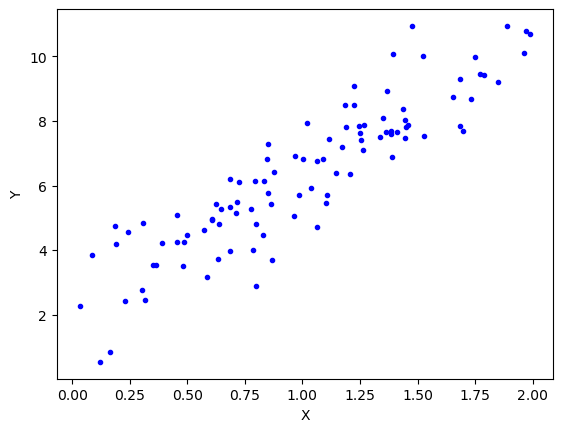

In [4]:
plt.plot(x,y, "b.")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Теперь можем перейти к обучению модели. Сразу выведу метрики

In [14]:

model = LinearRegression()
model.fit(X_learn, Y_learn)

y_pred = model.predict(X_learn)

model_r2_learn = r2_score(Y_learn, y_pred)
model_MSE_learn = np.sqrt(mean_squared_error(Y_learn, y_pred ))

print("MSE on learning: ", model_MSE_learn)
print("R2 on learnin: ", model_r2_learn)
print("Coefs: ", model.coef_ , model.intercept_)


MSE on learning:  0.7524214507947716
R2 on learnin:  0.8818683347364783
Coefs:  [4.13326516] 2.5434307395978077


Далее посмотрим на то, как данная модель поведёт себя на контрольной выборке

In [15]:
y_pred_control = model.predict(X_control)

model_r2_control = r2_score( Y_control, y_pred_control)
model_MSE_control = np.sqrt(mean_squared_error(Y_control, y_pred_control))

print("MSE on learning: ", model_MSE_control)
print("R2 on learnin: ", model_r2_control)
print("Coefs: ", model.coef_ , model.intercept_)

MSE on learning:  1.0392321869095436
R2 on learnin:  0.7172170008347568
Coefs:  [4.13326516] 2.5434307395978077


Как мы видим переобучения не получаетя добиться. Попробую добавить полиномиальные признаки в данные 

In [16]:

poly = PolynomialFeatures(degree = 15)
X_learn_poly = poly.fit_transform(X_learn)

model2 = LinearRegression()
model2.fit(X_learn_poly, Y_learn)

y_pred = model2.predict(X_learn_poly)

model_r2_learn = r2_score( Y_learn, y_pred)
model_MSE_learn = np.sqrt(mean_squared_error(Y_learn, y_pred ))

print("MSE on learning: ", model_MSE_learn)
print("R2 on learnin: ", model_r2_learn)
print("Coefs: ", model2.coef_ , model2.intercept_)

MSE on learning:  0.3389021304578728
R2 on learnin:  0.9760341637652574
Coefs:  [ 0.00000000e+00 -1.53859274e+06  1.29189704e+07 -6.19578061e+07
  1.88468974e+08 -3.77004693e+08  4.83763956e+08 -3.29269424e+08
 -6.00104020e+07  4.07987874e+08 -4.82751722e+08  3.29822857e+08
 -1.44957822e+08  4.05922237e+07 -6.62407438e+06  4.80933431e+05] 78752.51158916649


Можем видеть признаки переобучения , приверю точно ли это так на контрольной выборке

In [17]:
y_pred_control = model2.predict(poly.transform(X_control))

model_r2_control = r2_score(Y_control, y_pred_control)
model_MSE_control = np.sqrt(mean_squared_error(Y_control, y_pred_control))

print("MSE on learning: ", model_MSE_control)
print("R2 on learnin: ", model_r2_control)


MSE on learning:  1598.3935148420314
R2 on learnin:  -668951.8919393321


 на глаза все признаки переобучения. На контрольной выборке просто отправительный результат, попробую поправить ситуацию разными рягуляризованными регрессионными линейными моделями. Начну с греневой регрессии

In [18]:

ridge_reg = Ridge(alpha=1, solver="cholesky", random_state=42)
ridge_reg.fit(X_learn_poly, Y_learn)

y_pred = ridge_reg.predict(X_learn_poly)

model_r2_learn = r2_score( Y_learn, y_pred)
model_MSE_learn = np.sqrt(mean_squared_error( Y_learn, y_pred))

print("MSE on learning: ", model_MSE_learn)
print("R2 on learning: ", model_r2_learn)


y_pred_control = ridge_reg.predict(poly.transform(X_control))

model_r2_control = r2_score( Y_control, y_pred_control)
model_MSE_control = np.sqrt(mean_squared_error(Y_control, y_pred_control ))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)

print("разница между MSE: ",abs( model_MSE_learn - model_MSE_control))
print("Разница между R2: ", abs(model_r2_learn-model_r2_control))

MSE on learning:  0.6138825585756019
R2 on learning:  0.9213652376785486
MSE on control:  1.0714321804602207
R2 on control:  0.6994217923283914
разница между MSE:  0.4575496218846188
Разница между R2:  0.2219434453501572


Можно увидеть, что результат всё ещё далёк от идеала, однако гораздо лучше, чем было. Далее попробую применить лассо-регрессию

In [19]:

lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_learn_poly, Y_learn)

y_pred = lasso_model.predict(X_learn_poly)

model_r2_learn = r2_score(Y_learn, y_pred)
model_MSE_learn = np.sqrt(mean_squared_error(Y_learn, y_pred))

print("MSE on learning: ", model_MSE_learn)
print("R2 on learning: ", model_r2_learn)


y_pred_control = lasso_model.predict(poly.transform(X_control))

model_r2_control = r2_score(Y_control, y_pred_control)
model_MSE_control = np.sqrt(mean_squared_error( Y_control, y_pred_control))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)

print("разница между MSE: ",abs( model_MSE_learn - model_MSE_control))
print("Разница между R2: ", abs(model_r2_learn-model_r2_control))

MSE on learning:  0.8324686808847873
R2 on learning:  0.8553961698585881
MSE on control:  1.221857662515413
R2 on control:  0.6090966868510979
разница между MSE:  0.38938898163062563
Разница между R2:  0.24629948300749027


/home/ivankorolev/anaconda3/envs/envForML/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.116e+01, tolerance: 9.585e-03
  model = cd_fast.enet_coordinate_descent(


Здесь мы можем видеть результат хуже, наконец попробую эластичную сеть

In [20]:
elastic_model = ElasticNet(alpha=0.5)
elastic_model.fit(X_learn_poly, Y_learn)

y_pred = elastic_model.predict(X_learn_poly)

model_r2_learn = r2_score( Y_learn, y_pred)
model_MSE_learn = np.sqrt(mean_squared_error( Y_learn, y_pred))

print("MSE on learning: ", model_MSE_learn)
print("R2 on learning: ", model_r2_learn)


y_pred_control = elastic_model.predict(poly.transform(X_control))

model_r2_control = r2_score(Y_control, y_pred_control)
model_MSE_control = np.sqrt(mean_squared_error(Y_control, y_pred_control))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)

print("разница между MSE: ",abs( model_MSE_learn - model_MSE_control))
print("Разница между R2: ", abs(model_r2_learn-model_r2_control))

MSE on learning:  0.7666054942674712
R2 on learning:  0.8773725084664471
MSE on control:  1.2143910041750239
R2 on control:  0.6138596367331313
разница между MSE:  0.4477855099075527
Разница между R2:  0.26351287173331583


/home/ivankorolev/anaconda3/envs/envForML/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.616e+00, tolerance: 9.585e-03
  model = cd_fast.enet_coordinate_descent(


Посмотрев на разницы между метриками, я могу сделать вывод, что лучше всего себя показала лассо регрессия, её и проверим на результирующей выборке

In [21]:
y_res = lasso_model.predict(poly.transform(X_test))

model_r2_control = r2_score(y_res, Y_test )
model_MSE_control = np.sqrt(mean_squared_error( y_res,Y_test))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)

MSE on control:  1.7674358538958013
R2 on control:  -0.22094693360081274


Результат далёк от идеала, построим прямую по этим данным рядом с исходными и поссмотрим, что получается

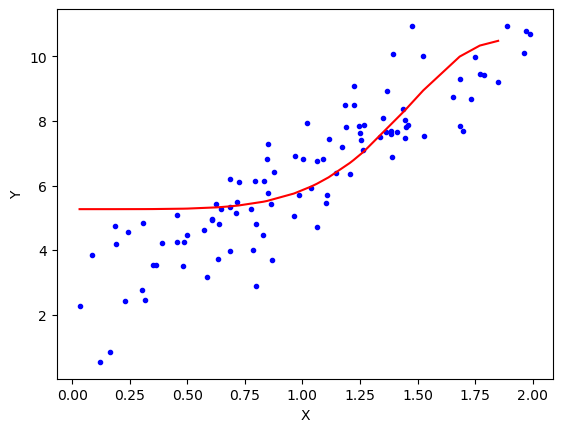

In [13]:
plt.plot(x,y, "b.")
plt.plot(sorted(X_test), sorted(y_res), "r-")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

как мы видим, этот метод убирает линейность, что не очень соотвествует заданию, также точность получислась весьма низзкой. в файле dz1_2 рассмотрю другой способ провоцирования переобучения и решения его на примере градиентного спуска